In [49]:
# Step 1: Install Required Libraries
# OR-Tools for optimization, OSMnx for road networks, Pyrosm for reading PBF files
# Folium for interactive maps, Geopy for address lookup
#!pip install ortools osmnx networkx pandas sqlalchemy psycopg2-binary matplotlib pyrosm folium geopy

In [2]:
import pandas as pd
import networkx as nx
import osmnx as ox
from sqlalchemy import create_engine
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 2: Load Historical Data
We fetch the data from your Supabase cloud to understand the traffic conditions.

In [ ]:
# Database Connection (Use your Transaction connection string)
import os
from dotenv import load_dotenv
load_dotenv()
DB_CONNECTION_STRING = os.getenv("DB_CONNECTION_STRING")
engine = create_engine(DB_CONNECTION_STRING)

# --- Data pull settings (controls how much historical + recent data you use) ---
TRAFFIC_ROWS = 50000  # increase for better historical patterns; decrease if query is slow
TRAFFIC_LOOKBACK_DAYS = 30  # only use last N days from the DB table (recommended)

INCIDENT_ROWS = 5000
INCIDENT_LOOKBACK_DAYS = 7

print("Fetching traffic data...")
# NOTE: In some setups this column is stored as TEXT in Postgres; casting makes time filtering work.
df_traffic = pd.read_sql(
    f"""
    SELECT *
    FROM traffic_flow
    WHERE ("timestamp"::timestamptz) >= (NOW() - INTERVAL '{TRAFFIC_LOOKBACK_DAYS} days')
    ORDER BY ("timestamp"::timestamptz) DESC
    LIMIT {TRAFFIC_ROWS}
    """,
    engine,
 )

print("Fetching incident data...")
try:
    df_incidents = pd.read_sql(
        f"""
        SELECT *
        FROM traffic_incidents
        WHERE ("timestamp"::timestamptz) >= (NOW() - INTERVAL '{INCIDENT_LOOKBACK_DAYS} days')
        ORDER BY ("timestamp"::timestamptz) DESC
        LIMIT {INCIDENT_ROWS}
        """,
        engine,
    )
except Exception as e:
    print(f"⚠️ Could not load traffic_incidents (continuing without incidents): {e}")
    df_incidents = pd.DataFrame()

# --- Time-based feature engineering (time of day, weekends, public holidays) ---
timestamp_col = "timestamp"
if timestamp_col not in df_traffic.columns:
    raise KeyError(f"Expected a '{timestamp_col}' column in traffic_flow results, got: {list(df_traffic.columns)}")

# Parse timestamps safely (assume UTC if timezone not provided)
df_traffic[timestamp_col] = pd.to_datetime(df_traffic[timestamp_col], errors="coerce", utc=True)

# Convert to Malaysia local time for human-relevant features
df_traffic["timestamp_local"] = df_traffic[timestamp_col].dt.tz_convert("Asia/Kuala_Lumpur")
df_traffic["date_local"] = df_traffic["timestamp_local"].dt.date
df_traffic["hour"] = df_traffic["timestamp_local"].dt.hour
df_traffic["day_of_week"] = df_traffic["timestamp_local"].dt.dayofweek  # Mon=0, Sun=6
df_traffic["is_weekend"] = df_traffic["day_of_week"].isin([5, 6])

def _time_of_day_from_hour(hour):
    if pd.isna(hour):
        return "unknown"
    hour = int(hour)
    if 0 <= hour < 6:
        return "night"
    if 6 <= hour < 10:
        return "morning_peak"
    if 10 <= hour < 16:
        return "midday"
    if 16 <= hour < 20:
        return "evening_peak"
    return "late_evening"

df_traffic["time_of_day"] = df_traffic["hour"].apply(_time_of_day_from_hour)

# Incident timestamps (if present)
if isinstance(df_incidents, pd.DataFrame) and len(df_incidents) > 0:
    if "timestamp" in df_incidents.columns:
        df_incidents["timestamp"] = pd.to_datetime(df_incidents["timestamp"], errors="coerce", utc=True)
        df_incidents["timestamp_local"] = df_incidents["timestamp"].dt.tz_convert("Asia/Kuala_Lumpur")
    if "start_time" in df_incidents.columns:
        df_incidents["start_time"] = pd.to_datetime(df_incidents["start_time"], errors="coerce", utc=True)
        df_incidents["start_time_local"] = df_incidents["start_time"].dt.tz_convert("Asia/Kuala_Lumpur")

# Public holiday indicator (Kuala Lumpur/Federal Territory)
try:
    import holidays  # pip install holidays
except ImportError:
    holidays = None

if holidays is not None and df_traffic["date_local"].notna().any():
    years = sorted({d.year for d in df_traffic["date_local"].dropna().tolist()})
    try:
        my_holidays = holidays.country_holidays("MY", subdiv="KUL", years=years)
    except Exception:
        # Fallbacks for older/newer versions of python-holidays
        try:
            my_holidays = holidays.MY(subdiv="KUL", years=years)
        except Exception:
            my_holidays = holidays.country_holidays("MY", years=years)
    df_traffic["is_public_holiday"] = df_traffic["date_local"].isin(my_holidays)
    df_traffic["public_holiday_name"] = df_traffic["date_local"].map(lambda d: my_holidays.get(d))
else:
    df_traffic["is_public_holiday"] = False
    df_traffic["public_holiday_name"] = None
    if holidays is None:
        print("Tip: install `holidays` to enable public-holiday features: pip install holidays")

# Calculate average speed across the city (Simple "Training" Metric)
avg_city_speed = df_traffic['speed'].mean()
print(f"Average City Speed (Historical): {avg_city_speed:.2f} km/h")
print(f"Rows loaded: traffic={len(df_traffic)} (lookback={TRAFFIC_LOOKBACK_DAYS} days), incidents={len(df_incidents)} (lookback={INCIDENT_LOOKBACK_DAYS} days)")
df_traffic.head()

Fetching traffic data...
Average City Speed (Historical): 9.56 km/h
Rows loaded: 50000 (lookback=30 days)


,location_description,speed,speed_limit,jam_factor,confidence,free_flow_speed,traversability,geometry,timestamp,hour,day_of_week,date,timestamp_local,date_local,is_weekend,time_of_day,is_public_holiday,public_holiday_name
0,Jalan Maharajalela/Jalan Kinabalu,6.111111,None,1.7,0.93,None,open,"[(101.694, 3.14072), (101.69415, 3.14073), (10...",2025-12-16 13:32:57.042215+00:00,21,1,2025-12-16,2025-12-16 21:32:57.042215+08:00,2025-12-16,False,late_evening,False,None
1,Lebuhraya Jalan Duta-Sungai Buloh,20.833334,None,0.5,0.99,None,open,"[(101.67252, 3.15335), (101.67221, 3.15385), (...",2025-12-16 13:32:57.042215+00:00,21,1,2025-12-16,2025-12-16 21:32:57.042215+08:00,2025-12-16,False,late_evening,False,None
2,Jalan Cenderasari,5.555556,None,0.0,0.70,None,open,"[(101.69163, 3.1457), (101.6917, 3.14564)]",2025-12-16 13:32:57.042215+00:00,21,1,2025-12-16,2025-12-16 21:32:57.042215+08:00,2025-12-16,False,late_evening,False,None
3,Jalan Tugu/Jalan Kinabalu,6.111111,None,0.8,0.96,None,open,"[(101.69356, 3.14126), (101.6936, 3.1412), (10...",2025-12-16 13:32:57.042215+00:00,21,1,2025-12-16,2025-12-16 21:32:57.042215+08:00,2025-12-16,False,late_evening,False,None
4,Jalan Tuanku Abdul Halim,12.777778,None,1.2,0.70,None,open,"[(101.68087, 3.15425), (101.68058, 3.15415), (...",2025-12-16 13:32:57.042215+00:00,21,1,2025-12-16,2025-12-16 21:32:57.042215+08:00,2025-12-16,False,late_evening,False,None


## Step 3: Build the Road Network
We use OSMnx to download the drivable road network for the area.

Loading road network for bbox: [101.65, 3.1, 101.75, 3.2]...
This may take a minute or two as the area is larger.
Graph created with 115484 nodes and 196579 edges.


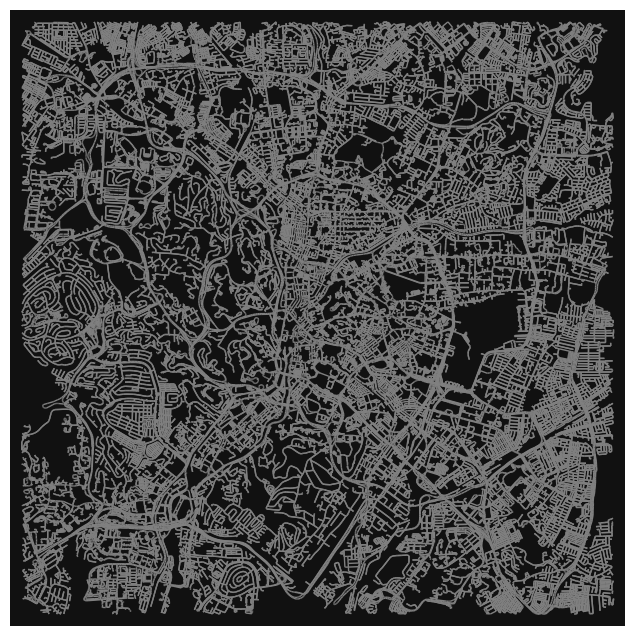

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
# Define the area to build the road network
# We will extract this area from the PBF file
# Bounding Box: [West, South, East, North]

# OLD (city center): bbox = [101.65, 3.10, 101.75, 3.20]
# NEW: wider Kuala Lumpur region for better geo-mapping coverage
# If this becomes too slow/heavy, shrink the box or reduce the road types.
bbox = [101.55, 3.00, 101.83, 3.30]

print(f"Loading road network for bbox: {bbox}...")
print("This may take longer as the area is larger.")

try:
    from pyrosm import OSM
    import os

    pbf_file = "malaysia-singapore-brunei-251009.osm.pbf"
    if not os.path.exists(pbf_file):
        raise FileNotFoundError(f"PBF file not found: {pbf_file}")

    # Initialize the OSM parser
    osm = OSM(pbf_file, bounding_box=bbox)

    # Get the driving network
    # nodes=True ensures we get node attributes like x, y
    nodes, edges = osm.get_network(network_type="driving", nodes=True)
    
    # Convert to NetworkX graph
    G = osm.to_graph(nodes, edges, graph_type="networkx")
    
    # Ensure CRS is set (Pyrosm usually returns WGS84)
    if not G.graph.get('crs'):
        G.graph['crs'] = 'epsg:4326'

except ImportError:
    print("❌ Pyrosm not installed or failed to load. Falling back to OSMnx API download.")
    # Fallback to API if Pyrosm fails
    north, south, east, west = bbox[3], bbox[1], bbox[2], bbox[0]
    G = ox.graph_from_bbox(bbox=(north, south, east, west), network_type='drive')

## Step 4: "Train" the Graph (Apply Traffic Data)
Here we use your historical data to update the travel times on the graph.

*   **Standard Approach**: Use speed limits.
*   **Your Data-Driven Approach**: Use actual historical speeds.

*(Note: For this tutorial, we apply a global congestion factor derived from your data. In a production system, you would map specific traffic coordinates to specific edges.)*

In [21]:
# Step 4: Apply congestion from real-time + historical data to road edges (name match + geospatial match)
# + Incorporate incident data + report unmapped roads

# This cell updates edge 'travel_time' so downstream shortest paths + VRP use it.
# It uses:
# - Recent observations ("real-time" proxy): last RECENT_WINDOW_MINUTES in your DB table
# - Historical patterns: same time_of_day + weekend/holiday bucket
# - Incidents: apply penalties/closures to impacted edges

import ast
import time
import numpy as np

# --- Tuning knobs ---
GEO_MATCH_ENABLED = True
GEO_MAX_RECORDS = 8000  # higher = more geo coverage, slower
RECENT_WINDOW_MINUTES = 60

INCIDENT_ACTIVE_WINDOW_MINUTES = 180  # consider incidents in last N minutes as active
INCIDENT_PENALTY_NONCRITICAL = 2.0  # multiplier applied to edges impacted by a non-critical incident
INCIDENT_CLOSE_ON_CRITICAL = True  # if True, critical incidents set travel_time = inf for impacted edges

STRICT_NO_PLACEHOLDERS = False  # True => edges with unknown base speed become unusable (travel_time = inf)

# Use a specific departure time (local) if you want to compare scenarios; otherwise uses "now"
DEPARTURE_TIME_LOCAL = None  # e.g. "2025-12-16 18:00"
LOCAL_TZ = "Asia/Kuala_Lumpur"

def _normalize_road_name(name):
    if name is None:
        return None
    if isinstance(name, list) and len(name) > 0:
        name = name[0]
    name = str(name)
    name = name.split("/")[0].strip().lower()
    name = " ".join(name.split())
    return name or None

def _num_col(df, col_name):
    if df is None or col_name not in df.columns:
        return pd.Series(pd.NA, index=df.index if df is not None else [], dtype="Float64")
    return pd.to_numeric(df[col_name], errors="coerce")

def _geometry_centroid_lonlat(geom_value):
    """Parse stored geometry (stringified list of (lon, lat)) and return (lon, lat) centroid."""
    if geom_value is None or (isinstance(geom_value, float) and pd.isna(geom_value)):
        return None
    try:
        coords = ast.literal_eval(geom_value) if isinstance(geom_value, str) else geom_value
    except Exception:
        return None
    if not coords or not isinstance(coords, (list, tuple)):
        return None
    sum_lon = 0.0
    sum_lat = 0.0
    count = 0
    for pt in coords:
        if not isinstance(pt, (list, tuple)) or len(pt) < 2:
            continue
        try:
            lon = float(pt[0])
            lat = float(pt[1])
        except Exception:
            continue
        sum_lon += lon
        sum_lat += lat
        count += 1
    if count == 0:
        return None
    return (sum_lon / count, sum_lat / count)

def _iter_nearest_edges(nearest, expected_n):
    """Yield (u, v, k) from ox.distance.nearest_edges return value across OSMnx versions."""
    if isinstance(nearest, tuple) and len(nearest) == 3:
        us, vs, ks = nearest
        for u_e, v_e, k_e in zip(us, vs, ks):
            yield u_e, v_e, k_e
        return

    if isinstance(nearest, (list, tuple)) and len(nearest) > 0:
        first = nearest[0]
        if isinstance(first, (list, tuple, np.ndarray)):
            for e in nearest:
                e = list(e)
                if len(e) >= 3:
                    yield e[0], e[1], e[2]
                elif len(e) == 2:
                    yield e[0], e[1], None
            return

    if isinstance(nearest, np.ndarray):
        arr = np.asarray(nearest)
        if arr.ndim == 1 and len(arr) == expected_n:
            for item in arr:
                if isinstance(item, (list, tuple, np.ndarray)):
                    item = list(item)
                    if len(item) >= 3:
                        yield item[0], item[1], item[2]
                    elif len(item) == 2:
                        yield item[0], item[1], None
            return
        if arr.ndim == 2:
            if arr.shape[0] == expected_n and arr.shape[1] in (2, 3):
                use = arr
            elif arr.shape[1] == expected_n and arr.shape[0] in (2, 3):
                use = arr.T
            else:
                use = None
            if use is not None:
                for row in use:
                    if len(row) >= 3:
                        yield row[0], row[1], row[2]
                    else:
                        yield row[0], row[1], None
                return

def _is_critical_incident(criticality_value):
    if criticality_value is None:
        return False
    s = str(criticality_value).strip().lower()
    # HERE criticality values often like: "critical", "major", "minor", etc.
    return s in {"critical", "high", "major"}

t0 = time.time()

# 0) Ensure graph has baseline free-flow speed + travel time from OSM tags (not hard-coded)
is_multigraph = isinstance(G, (nx.MultiDiGraph, nx.MultiGraph))
edge_iter_for_check = G.edges(keys=True, data=True) if is_multigraph else ((u, v, None, d) for u, v, d in G.edges(data=True))

has_speed_kph = False
has_tt = False
for _, _, _, d in edge_iter_for_check:
    if "speed_kph" in d:
        has_speed_kph = True
    if "travel_time" in d:
        has_tt = True
    if has_speed_kph and has_tt:
        break

if not has_speed_kph:
    G = ox.add_edge_speeds(G)  # derives speed_kph from maxspeed/highway tags
if not has_tt:
    G = ox.add_edge_travel_times(G)  # derives travel_time from length + speed_kph

# 1) Choose a target "departure" time (local) so we can slice historical patterns
now_local = pd.Timestamp.now(tz=LOCAL_TZ)
if DEPARTURE_TIME_LOCAL:
    target_local = pd.Timestamp(DEPARTURE_TIME_LOCAL, tz=LOCAL_TZ)
else:
    target_local = now_local

target_time_of_day = None
target_is_weekend = None
target_is_holiday = None
if "time_of_day" in df_traffic.columns:
    target_time_of_day = (
        "night" if target_local.hour < 6
        else "morning_peak" if target_local.hour < 10
        else "midday" if target_local.hour < 16
        else "evening_peak" if target_local.hour < 20
        else "late_evening"
    )
target_is_weekend = target_local.dayofweek in (5, 6)
if "is_public_holiday" in df_traffic.columns:
    try:
        target_is_holiday = bool(
            df_traffic.get("date_local", pd.Series([None])).isin([target_local.date()]).any()
            and df_traffic.loc[df_traffic["date_local"] == target_local.date(), "is_public_holiday"].iloc[0]
        )
    except Exception:
        target_is_holiday = None

# 2) Compute speed_factor for each traffic row (vectorized)
speed = _num_col(df_traffic, "speed")
ff = _num_col(df_traffic, "free_flow_speed")
sl = _num_col(df_traffic, "speed_limit")
jf = _num_col(df_traffic, "jam_factor")

speed_factor = pd.Series(pd.NA, index=df_traffic.index, dtype="Float64")

mask = speed.notna() & ff.notna() & (ff > 0)
speed_factor.loc[mask] = (speed.loc[mask] / ff.loc[mask]).astype(float)

mask2 = speed_factor.isna() & speed.notna() & sl.notna() & (sl > 0)
speed_factor.loc[mask2] = (speed.loc[mask2] / sl.loc[mask2]).astype(float)

mask3 = speed_factor.isna() & jf.notna()
speed_factor.loc[mask3] = (1.0 - (jf.loc[mask3].astype(float) / 10.0))

speed_factor = speed_factor.clip(lower=0.05, upper=1.0)

# Keep a dataframe with speed_factor for later steps (sampling/statistics)
df_sf = df_traffic.copy()
df_sf["_speed_factor"] = speed_factor

# 3) Split traffic into recent ("real-time") + historical slice
if "timestamp_local" in df_sf.columns:
    recent_cutoff = target_local - pd.Timedelta(minutes=RECENT_WINDOW_MINUTES)
    df_recent = df_sf[df_sf["timestamp_local"].notna() & (df_sf["timestamp_local"] >= recent_cutoff)]
else:
    df_recent = df_sf.iloc[0:0].copy()
df_hist = df_sf

# Historical slice: same time_of_day/weekend/holiday bucket when available
if target_time_of_day and "time_of_day" in df_hist.columns:
    df_hist = df_hist[df_hist["time_of_day"] == target_time_of_day]
if target_is_weekend is not None and "is_weekend" in df_hist.columns:
    df_hist = df_hist[df_hist["is_weekend"] == bool(target_is_weekend)]
if target_is_holiday is not None and "is_public_holiday" in df_hist.columns:
    df_hist = df_hist[df_hist["is_public_holiday"] == bool(target_is_holiday)]

# 4) Build name-based speed lookup (recent overrides historical)
def _build_name_lookup(df_in):
    if df_in is None or len(df_in) == 0 or "location_description" not in df_in.columns:
        return {}
    parts = (
        df_in["location_description"]
        .astype(str)
        .str.split("/")
        .explode()
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({"": pd.NA})
    )
    sf_rep = df_in["_speed_factor"].reindex(parts.index)
    grouped = sf_rep.groupby(parts).mean()
    return grouped.dropna().to_dict()

speed_factor_by_road_recent = _build_name_lookup(df_recent)
speed_factor_by_road_hist = _build_name_lookup(df_hist)

# 5) Build geo edge mapping (recent overrides historical)
def _build_geo_edge_lookup(df_in):
    if not GEO_MATCH_ENABLED or df_in is None or len(df_in) == 0 or ("geometry" not in df_in.columns):
        return {}, 0, 0, 0
    df_geo = df_in[["geometry", "_speed_factor"]].copy()
    df_geo = df_geo.dropna(subset=["geometry", "_speed_factor"])
    if len(df_geo) > GEO_MAX_RECORDS:
        df_geo = df_geo.head(GEO_MAX_RECORDS)

    geo_grouped = (
        df_geo.groupby("geometry")["_speed_factor"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "sf_mean", "count": "n"})
    )
    geo_unique = len(geo_grouped)

    xs, ys, sf_means, ns = [], [], [], []
    centroid_failures = 0
    for geom_value, sf_mean, n in zip(geo_grouped["geometry"], geo_grouped["sf_mean"], geo_grouped["n"]):
        centroid = _geometry_centroid_lonlat(geom_value)
        if centroid is None:
            centroid_failures += 1
            continue
        lon, lat = centroid
        xs.append(lon)
        ys.append(lat)
        sf_means.append(float(sf_mean))
        ns.append(int(n))

    if not xs:
        return {}, 0, geo_unique, centroid_failures

    nearest = ox.distance.nearest_edges(G, X=xs, Y=ys)
    edge_rows = []
    for (u_e, v_e, k_e), sf_mean, n in zip(_iter_nearest_edges(nearest, expected_n=len(sf_means)), sf_means, ns):
        if k_e is not None:
            try:
                k_e = int(k_e)
            except Exception:
                k_e = None
        edge_rows.append((u_e, v_e, k_e, sf_mean, n))

    if not edge_rows:
        return {}, 0, geo_unique, centroid_failures

    tmp_edges = pd.DataFrame(edge_rows, columns=["u", "v", "k", "sf_mean", "n"])
    tmp_edges["weighted_sf"] = tmp_edges["sf_mean"] * tmp_edges["n"]
    agg = tmp_edges.groupby(["u", "v", "k"]).agg(weighted_sf_sum=("weighted_sf", "sum"), n_sum=("n", "sum")).reset_index()
    agg["sf"] = (agg["weighted_sf_sum"] / agg["n_sum"]).astype(float)
    speed_factor_by_edge = {(row.u, row.v, row.k): float(row.sf) for row in agg.itertuples(index=False)}
    mapped_records = int(tmp_edges["n"].sum())
    return speed_factor_by_edge, mapped_records, geo_unique, centroid_failures

speed_factor_by_edge_recent, mapped_recent, unique_recent, centroid_fail_recent = _build_geo_edge_lookup(df_recent)
speed_factor_by_edge_hist, mapped_hist, unique_hist, centroid_fail_hist = _build_geo_edge_lookup(df_hist)

# 6) Global fallback speed factor: computed from available traffic in the chosen bucket
def _global_sf(df_in):
    if df_in is None or len(df_in) == 0:
        return None
    vals = pd.to_numeric(df_in.get("_speed_factor"), errors="coerce")
    if not isinstance(vals, pd.Series):
        return None
    vals = vals.dropna()
    if len(vals) == 0:
        return None
    return float(vals.mean())

global_sf_recent = _global_sf(df_recent)
global_sf_hist = _global_sf(df_hist)
global_speed_factor = global_sf_recent if global_sf_recent is not None else global_sf_hist
if global_speed_factor is None:
    raise ValueError("No usable traffic data to compute congestion (speed/free_flow_speed/speed_limit/jam_factor all missing).")

city_congestion_index = 1.0 - global_speed_factor
print(f"Departure time (local): {target_local}")
print(f"Recent window: last {RECENT_WINDOW_MINUTES} minutes; recent rows: {len(df_recent)}; hist rows in bucket: {len(df_hist)}")
print(f"Global speed factor: {global_speed_factor:.2f} (city congestion index: {city_congestion_index:.2f})")
print(f"Geo edges (recent): {len(speed_factor_by_edge_recent)} from {mapped_recent} records (unique geometries: {unique_recent}, centroid-fail: {centroid_fail_recent})")
print(f"Geo edges (hist): {len(speed_factor_by_edge_hist)} from {mapped_hist} records (unique geometries: {unique_hist}, centroid-fail: {centroid_fail_hist})")

# 6.5) Map active incidents to edges (geo)
incident_penalty_by_edge = {}
active_incidents = 0
if isinstance(globals().get("df_incidents"), pd.DataFrame) and len(df_incidents) > 0 and "geometry" in df_incidents.columns:
    incident_cutoff = target_local - pd.Timedelta(minutes=INCIDENT_ACTIVE_WINDOW_MINUTES)
    ts_col = "timestamp_local" if "timestamp_local" in df_incidents.columns else None
    if ts_col is not None:
        df_active_inc = df_incidents[df_incidents[ts_col].notna() & (df_incidents[ts_col] >= incident_cutoff)].copy()
    else:
        df_active_inc = df_incidents.copy()

    if len(df_active_inc) > 0:
        active_incidents = len(df_active_inc)
        xs_i, ys_i, penalties = [], [], []
        crit_series = df_active_inc["criticality"] if "criticality" in df_active_inc.columns else pd.Series([None] * len(df_active_inc))
        for geom_value, crit in zip(df_active_inc["geometry"], crit_series):
            centroid = _geometry_centroid_lonlat(geom_value)
            if centroid is None:
                continue
            lon, lat = centroid
            xs_i.append(lon)
            ys_i.append(lat)
            is_crit = _is_critical_incident(crit)
            if is_crit and INCIDENT_CLOSE_ON_CRITICAL:
                penalties.append(float("inf"))
            else:
                penalties.append(float(INCIDENT_PENALTY_NONCRITICAL))
        if xs_i:
            nearest_i = ox.distance.nearest_edges(G, X=xs_i, Y=ys_i)
            for (u_e, v_e, k_e), pen in zip(_iter_nearest_edges(nearest_i, expected_n=len(xs_i)), penalties):
                if k_e is not None:
                    try:
                        k_e = int(k_e)
                    except Exception:
                        k_e = None
                key = (u_e, v_e, k_e)
                # Keep the strongest penalty (inf > finite)
                prev = incident_penalty_by_edge.get(key)
                if prev is None or (np.isinf(pen) and not np.isinf(prev)) or (not np.isinf(pen) and not np.isinf(prev) and pen > prev):
                    incident_penalty_by_edge[key] = pen

print(f"Active incidents considered: {active_incidents}; incident-impacted edges: {len(incident_penalty_by_edge)}")

# 7) Update edge weights (travel time) + attach congestion index
edge_matches_geo = 0
edge_matches_name = 0
edge_used_strict_inf = 0
edge_incident_impacted = 0
total_edges = 0
unmapped_road_counts = {}

edge_iter = G.edges(keys=True, data=True) if is_multigraph else ((u, v, None, d) for u, v, d in G.edges(data=True))
for u, v, k, data in edge_iter:
    total_edges += 1

    base_tt = data.get("travel_time")
    if base_tt is None:
        if STRICT_NO_PLACEHOLDERS:
            data["free_flow_travel_time"] = None
            data["travel_time"] = float("inf")
            data["congestion_index"] = 1.0
            data["estimated_speed_kph"] = None
            edge_used_strict_inf += 1
            continue
        else:
            length_m = data.get("length")
            speed_kph = data.get("speed_kph")
            if length_m is not None and speed_kph is not None and float(speed_kph) > 0:
                base_tt = float(length_m) / (float(speed_kph) * 1000 / 3600)
            else:
                base_tt = None

    # Choose best available speed_factor: geo recent -> geo hist -> name recent -> name hist -> global
    speed_factor_edge = global_speed_factor
    edge_key = (u, v, k)
    rev_key = (v, u, k)

    if edge_key in speed_factor_by_edge_recent:
        speed_factor_edge = float(speed_factor_by_edge_recent[edge_key])
        edge_matches_geo += 1
    elif rev_key in speed_factor_by_edge_recent:
        speed_factor_edge = float(speed_factor_by_edge_recent[rev_key])
        edge_matches_geo += 1
    elif edge_key in speed_factor_by_edge_hist:
        speed_factor_edge = float(speed_factor_by_edge_hist[edge_key])
        edge_matches_geo += 1
    elif rev_key in speed_factor_by_edge_hist:
        speed_factor_edge = float(speed_factor_by_edge_hist[rev_key])
        edge_matches_geo += 1
    else:
        road_key = _normalize_road_name(data.get("name"))
        if road_key and road_key in speed_factor_by_road_recent:
            speed_factor_edge = float(speed_factor_by_road_recent[road_key])
            edge_matches_name += 1
        elif road_key and road_key in speed_factor_by_road_hist:
            speed_factor_edge = float(speed_factor_by_road_hist[road_key])
            edge_matches_name += 1
        # Track unmapped (geo) roads for reporting
        if road_key:
            unmapped_road_counts[road_key] = unmapped_road_counts.get(road_key, 0) + 1

    speed_factor_edge = float(max(0.05, min(1.0, speed_factor_edge)))
    congestion_index = float(1.0 - speed_factor_edge)

    data["free_flow_travel_time"] = base_tt
    if base_tt is None:
        if STRICT_NO_PLACEHOLDERS:
            data["travel_time"] = float("inf")
            data["estimated_speed_kph"] = None
            edge_used_strict_inf += 1
        else:
            # No travel_time update (avoid inventing).
            pass
    else:
        data["travel_time"] = float(base_tt) / speed_factor_edge
        sk = data.get("speed_kph")
        data["estimated_speed_kph"] = (float(sk) * speed_factor_edge) if sk is not None else None

    data["congestion_index"] = congestion_index

    # Apply incident penalty/closure (if any)
    pen = incident_penalty_by_edge.get(edge_key)
    if pen is None:
        pen = incident_penalty_by_edge.get(rev_key)
    if pen is not None:
        data["incident_active"] = True
        data["incident_penalty"] = pen
        edge_incident_impacted += 1
        if np.isinf(pen):
            data["travel_time"] = float("inf")
        else:
            if data.get("travel_time") is not None and np.isfinite(data.get("travel_time")):
                data["travel_time"] = float(data["travel_time"]) * float(pen)
    else:
        data["incident_active"] = False
        data["incident_penalty"] = None

print(
    "Graph weights updated. ",
    f"Geo-matched edges: {edge_matches_geo}/{total_edges}, ",
    f"Name-matched edges: {edge_matches_name}/{total_edges}, ",
    f"Incident-impacted edges: {edge_incident_impacted}/{total_edges}, ",
    f"Strict-inf edges: {edge_used_strict_inf}/{total_edges}.",
 )

# 8) Report roads with no geo match (by edge count)
if unmapped_road_counts:
    top_unmapped = sorted(unmapped_road_counts.items(), key=lambda x: x[1], reverse=True)[:15]
    print("Top road names with NO geo-match (edge count):")
    for name, cnt in top_unmapped:
        print(f"  - {name}: {cnt}")

print(f"Step 4 runtime: {time.time() - t0:.2f}s")

Departure time (local): 2025-12-16 22:09:47.586809+08:00
Recent window: last 60 minutes; recent rows: 334; hist rows in bucket: 6019
Global speed factor: 0.86 (city congestion index: 0.14)
Geo edges (recent): 323 from 334 records (unique geometries: 334, centroid-fail: 0)
Geo edges (hist): 328 from 6019 records (unique geometries: 339, centroid-fail: 0)
Active incidents considered: 0; incident-impacted edges: 0
Graph weights updated.  Geo-matched edges: 392/196579,  Name-matched edges: 6955/196579,  Incident-impacted edges: 0/196579,  Strict-inf edges: 0/196579.
Top road names with NO geo-match (edge count):
  - jalan 1: 1759
  - jalan 2: 892
  - jalan 3: 652
  - jalan 5: 609
  - jalan tun razak: 553
  - jalan tun ismail: 527
  - jalan ampang: 517
  - jalan 4: 490
  - jalan damansara: 458
  - lebuhraya duke: 420
  - lebuhraya spe: 385
  - lingkaran wawasan: 354
  - jalan pahang: 345
  - jalan sultan ismail: 328
  - jalan 6: 311
Step 4 runtime: 13.68s


## Step 5: Define Delivery Problem (Landmarks)
Instead of random points, we will use **6 real locations** in Kuala Lumpur to simulate a realistic delivery route:
*   **Depot**: KL Sentral
*   **Stops**: Suria KLCC, Pavilion KL, Berjaya Times Square, National Mosque, Merdeka Square

We will geocode these addresses to find their nearest road nodes and compute the travel times.

In [19]:
from geopy.geocoders import Nominatim
import time

# Initialize Geocoder
geolocator = Nominatim(user_agent="traffic_optimizer_app_vrp")

# Define our Delivery List
delivery_locations = [
    {"name": "Depot (KL Sentral)", "address": "KL Sentral, Kuala Lumpur"},
    {"name": "Suria KLCC", "address": "Suria KLCC, Kuala Lumpur"},
    {"name": "Pavilion KL", "address": "Pavilion Kuala Lumpur, Kuala Lumpur"},
    {"name": "Berjaya Times Square", "address": "Berjaya Times Square, Kuala Lumpur"},
    {"name": "National Mosque", "address": "Masjid Negara, Kuala Lumpur"},
    {"name": "Merdeka Square", "address": "Dataran Merdeka, Kuala Lumpur"}
]

locations = [] # Will store graph node IDs
location_names = [] # Will store names for the map

print("📍 Geocoding Locations and mapping to road network...")

for loc in delivery_locations:
    try:
        # 1. Geocode Address
        location = geolocator.geocode(loc["address"])
        if not location:
            print(f"⚠️ Could not find address: {loc['address']}")
            continue
            
        # 2. Find Nearest Graph Node
        node = ox.nearest_nodes(G, location.longitude, location.latitude)
        
        locations.append(node)
        location_names.append(loc["name"])
        
        print(f"✅ {loc['name']}: Found at ({location.latitude:.4f}, {location.longitude:.4f}) -> Node {node}")
        
        # Be nice to the API
        time.sleep(1)
        
    except Exception as e:
        print(f"❌ Error processing {loc['name']}: {e}")

print(f"\nSuccessfully mapped {len(locations)} locations.")

if len(locations) < 2:
    raise ValueError("Not enough locations found to run VRP. Please check addresses or internet connection.")

# 3. Compute Time Matrix
print("\nComputing Time Matrix...")
time_matrix = []
for start_node in locations:
    row = []
    for end_node in locations:
        if start_node == end_node:
            row.append(0)
        else:
            try:
                length = nx.shortest_path_length(G, start_node, end_node, weight='travel_time')
                row.append(int(length))
            except nx.NetworkXNoPath:
                row.append(999999)
    time_matrix.append(row)

print("✅ Time Matrix computed successfully.")

📍 Geocoding Locations and mapping to road network...
✅ Depot (KL Sentral): Found at (3.1343, 101.6864) -> Node 5434837049
✅ Suria KLCC: Found at (3.1574, 101.7124) -> Node 12734231875
✅ Pavilion KL: Found at (3.1492, 101.7130) -> Node 10185182534
✅ Berjaya Times Square: Found at (3.1422, 101.7105) -> Node 11899746751
❌ Error processing National Mosque: HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /search?q=Masjid+Negara%2C+Kuala+Lumpur&format=json&limit=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))
✅ Merdeka Square: Found at (3.1488, 101.6936) -> Node 7050604610

Successfully mapped 5 locations.

Computing Time Matrix...
✅ Time Matrix computed successfully.


## Step 6: Solve Vehicle Routing Problem (VRP)
We use Google OR-Tools to find the optimal order to visit all 5 stops and return to the depot.

In [22]:
import numpy as np

# --- VRP enhancements ---
# 1) Time windows (optional)
# 2) Service times (optional)
# 3) Time-dependent routing (iterative approximation)
# 4) Sampling (scenario re-solves)

# Configure these as needed (minutes)
HORIZON_MINUTES = 6 * 60
WAITING_SLACK_MINUTES = 60  # max waiting allowed at a stop to satisfy its time window
TIME_DEPENDENT_ITERATIONS = 2  # 1 = static only, 2+ = iterative time-dependent refinement

# Time windows are in minutes since departure. Default: no constraints (0..horizon).
# Example to enforce windows:
# TIME_WINDOWS_MINUTES = [(0, HORIZON_MINUTES), (30, 180), (0, 240), (60, 300), (0, 360), (0, 360)]
TIME_WINDOWS_MINUTES = None

# Service times per stop in minutes (time spent at location). Default: 0 at all stops.
# Example: SERVICE_TIMES_MINUTES = [0, 10, 10, 10, 15, 10]
SERVICE_TIMES_MINUTES = None

# Sampling settings
ENABLE_SAMPLING = True
N_SCENARIOS = 7  # keep small; each scenario solves VRP once
SCENARIO_METHOD = "quantiles"  # 'quantiles' | 'bootstrap'
QUANTILES = [0.2, 0.5, 0.8]

def _build_sf_by_hour(df_sf, fallback_sf):
    if not isinstance(df_sf, pd.DataFrame):
        return {}
    if "timestamp_local" not in df_sf.columns or "_speed_factor" not in df_sf.columns:
        return {}
    tmp = df_sf[["timestamp_local", "_speed_factor"]].copy()
    tmp = tmp.dropna(subset=["timestamp_local", "_speed_factor"])
    if len(tmp) == 0:
        return {}
    hours = tmp["timestamp_local"].dt.hour
    vals = pd.to_numeric(tmp["_speed_factor"], errors="coerce")
    grp = vals.groupby(hours).mean().dropna()
    d = {int(h): float(v) for h, v in grp.items()}
    # Fill missing hours with fallback for stability
    for h in range(24):
        d.setdefault(h, float(fallback_sf))
    return d

def _to_seconds_list(minutes_list, n, default_value=0):
    if minutes_list is None:
        return [int(default_value)] * n
    if len(minutes_list) != n:
        raise ValueError(f"Expected list length {n}, got {len(minutes_list)}")
    return [int(m * 60) for m in minutes_list]

def _to_time_windows_seconds(time_windows_minutes, n, horizon_minutes):
    if time_windows_minutes is None:
        return [(0, int(horizon_minutes * 60))] * n
    if len(time_windows_minutes) != n:
        raise ValueError(f"Expected {n} time windows, got {len(time_windows_minutes)}")
    out = []
    for w in time_windows_minutes:
        if w is None:
            out.append((0, int(horizon_minutes * 60)))
            continue
        start_m, end_m = w
        out.append((int(start_m * 60), int(end_m * 60)))
    return out

def solve_vrp_with_time_constraints(time_matrix_s, time_windows_s=None, service_times_s=None, horizon_s=None, slack_s=0):
    n = len(time_matrix_s)
    horizon_s = int(horizon_s) if horizon_s is not None else int(HORIZON_MINUTES * 60)
    time_windows_s = time_windows_s or [(0, horizon_s)] * n
    service_times_s = service_times_s or [0] * n

    manager = pywrapcp.RoutingIndexManager(n, 1, 0)
    routing = pywrapcp.RoutingModel(manager)

    def time_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        travel = int(time_matrix_s[from_node][to_node])
        service = int(service_times_s[from_node])
        return travel + service

    transit_callback_index = routing.RegisterTransitCallback(time_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    routing.AddDimension(
        transit_callback_index,
        int(slack_s),
        int(horizon_s),
        True,
        "Time",
    )
    time_dimension = routing.GetDimensionOrDie("Time")

    # Apply time windows
    for loc_idx, (start_s, end_s) in enumerate(time_windows_s):
        idx = manager.NodeToIndex(loc_idx)
        time_dimension.CumulVar(idx).SetRange(int(start_s), int(end_s))

    # Strongly encourage feasible time window solutions
    for vehicle_id in range(1):
        routing.AddVariableMinimizedByFinalizer(time_dimension.CumulVar(routing.Start(vehicle_id)))
        routing.AddVariableMinimizedByFinalizer(time_dimension.CumulVar(routing.End(vehicle_id)))

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.seconds = 10

    solution = routing.SolveWithParameters(search_parameters)
    return manager, routing, solution

def extract_route_order(manager, routing, solution):
    # Returns list of node indices in visit order starting at depot and ending at depot.
    if not solution:
        return None
    order = []
    index = routing.Start(0)
    while not routing.IsEnd(index):
        order.append(manager.IndexToNode(index))
        index = solution.Value(routing.NextVar(index))
    order.append(manager.IndexToNode(index))
    return order

def simulate_route_time_dependent(route_order, base_time_matrix_s, service_times_s, departure_local, sf_by_hour, fallback_sf):
    if route_order is None:
        return None
    t = 0.0  # seconds since departure
    arrivals = {route_order[0]: 0.0}
    departures = {route_order[0]: 0.0}

    for i in range(len(route_order) - 1):
        a = route_order[i]
        b = route_order[i + 1]
        depart_local = departure_local + pd.Timedelta(seconds=float(t))
        hour = int(depart_local.hour)
        sf_h = float(sf_by_hour.get(hour, fallback_sf))
        # If sf_h < fallback => multiplier > 1 (slower), and vice-versa.
        mult = float(fallback_sf) / max(0.05, min(1.0, sf_h))
        travel = float(base_time_matrix_s[a][b]) * mult
        t += travel
        arrivals[b] = t
        # service time at b is added before departing for next leg (except final depot return doesn’t matter much)
        t += float(service_times_s[b])
        departures[b] = t

    total = float(t)
    return {"arrivals_s": arrivals, "departures_s": departures, "total_s": total}

def build_node_departure_times(route_sim, n):
    # departure time per node index (seconds since departure), default 0
    dep = [0] * n
    if not route_sim:
        return dep
    departures = route_sim.get("departures_s", {})
    for node_idx, t in departures.items():
        dep[int(node_idx)] = int(t)
    return dep

def build_time_dependent_matrix_from_departures(base_time_matrix_s, node_departure_times_s, departure_local, sf_by_hour, fallback_sf):
    n = len(base_time_matrix_s)
    out = [[0] * n for _ in range(n)]
    for i in range(n):
        depart_local_i = departure_local + pd.Timedelta(seconds=float(node_departure_times_s[i]))
        hour = int(depart_local_i.hour)
        sf_h = float(sf_by_hour.get(hour, fallback_sf))
        mult = float(fallback_sf) / max(0.05, min(1.0, sf_h))
        row = out[i]
        base_row = base_time_matrix_s[i]
        for j in range(n):
            if i == j:
                row[j] = 0
            else:
                row[j] = int(float(base_row[j]) * mult)
    return out

def route_to_string(route_order):
    if route_order is None:
        return "(no route)"
    parts = []
    for idx in route_order:
        if 'location_names' in globals() and idx < len(location_names):
            parts.append(location_names[idx])
        else:
            parts.append(f"Stop {idx}")
    return " -> ".join(parts)

# --- Build constraints ---
n = len(time_matrix)
time_windows_s = _to_time_windows_seconds(TIME_WINDOWS_MINUTES, n, HORIZON_MINUTES)
service_times_s = _to_seconds_list(SERVICE_TIMES_MINUTES, n, default_value=0)
horizon_s = int(HORIZON_MINUTES * 60)
slack_s = int(WAITING_SLACK_MINUTES * 60)

departure_local = globals().get("target_local")
if departure_local is None:
    departure_local = pd.Timestamp.now(tz=LOCAL_TZ if 'LOCAL_TZ' in globals() else None)

fallback_sf = float(globals().get("global_speed_factor", 1.0))
sf_by_hour = _build_sf_by_hour(globals().get("df_sf"), fallback_sf=fallback_sf)

# --- Time-dependent iterative solve ---
base_time_matrix_s = time_matrix
best = None
current_matrix = base_time_matrix_s
for it in range(max(1, int(TIME_DEPENDENT_ITERATIONS))):
    manager, routing, solution = solve_vrp_with_time_constraints(
        current_matrix,
        time_windows_s=time_windows_s,
        service_times_s=service_times_s,
        horizon_s=horizon_s,
        slack_s=slack_s,
    )
    route_order = extract_route_order(manager, routing, solution)
    if not solution:
        print("❌ No VRP solution found (time windows may be too tight).")
        best = None
        break

    sim = simulate_route_time_dependent(
        route_order,
        base_time_matrix_s=base_time_matrix_s,
        service_times_s=service_times_s,
        departure_local=departure_local,
        sf_by_hour=sf_by_hour,
        fallback_sf=fallback_sf,
    )
    total_td_min = sim["total_s"] / 60.0
    objective_min = solution.ObjectiveValue() / 60.0
    best = {
        "route_order": route_order,
        "solution": solution,
        "objective_min": objective_min,
        "total_td_min": total_td_min,
        "iteration": it,
    }
    # Build next iteration's matrix using estimated node departure times from simulation
    if it < int(TIME_DEPENDENT_ITERATIONS) - 1:
        node_dep = build_node_departure_times(sim, n)
        current_matrix = build_time_dependent_matrix_from_departures(
            base_time_matrix_s, node_dep, departure_local, sf_by_hour, fallback_sf
        )

if best:
    print("✅ Solution Found!")
    print(f"⏱️ OR-Tools objective (static matrix): {best['objective_min']:.2f} minutes")
    print(f"⏱️ Simulated total (time-dependent): {best['total_td_min']:.2f} minutes")
    print(f"🔁 Time-dependent iterations used: {best['iteration'] + 1}")
    print("Route Order:")
    print(route_to_string(best["route_order"]))
else:
    print("❌ No solution found!")

# --- Sampling scenarios ---
if ENABLE_SAMPLING and isinstance(globals().get("df_hist"), pd.DataFrame) and "_speed_factor" in df_hist.columns:
    sf_vals = pd.to_numeric(df_hist["_speed_factor"], errors="coerce").dropna()
    if len(sf_vals) > 50:
        scenarios = []
        if SCENARIO_METHOD == "bootstrap":
            rng = np.random.default_rng(42)
            # Sample mean speed_factor from bootstrapped draws (keeps scenarios realistic)
            for _ in range(int(N_SCENARIOS)):
                sample = rng.choice(sf_vals.to_numpy(), size=min(500, len(sf_vals)), replace=True)
                scenarios.append(float(np.mean(sample)))
        else:
            # quantiles
            qs = QUANTILES if QUANTILES else [0.2, 0.5, 0.8]
            scenarios = [float(sf_vals.quantile(q)) for q in qs]
            # pad to N_SCENARIOS with random draws if needed
            if len(scenarios) < int(N_SCENARIOS):
                rng = np.random.default_rng(42)
                extra = rng.choice(sf_vals.to_numpy(), size=int(N_SCENARIOS) - len(scenarios), replace=True)
                scenarios.extend([float(x) for x in extra])

        results = []
        for i, sf_s in enumerate(scenarios[: int(N_SCENARIOS)]):
            sf_s = float(max(0.05, min(1.0, sf_s)))
            # Scale base travel times by relative congestion
            mult = float(fallback_sf) / sf_s
            matrix_s = (np.array(base_time_matrix_s, dtype=float) * mult).round().astype(int).tolist()
            m_s, r_s, sol_s = solve_vrp_with_time_constraints(
                matrix_s,
                time_windows_s=time_windows_s,
                service_times_s=service_times_s,
                horizon_s=horizon_s,
                slack_s=slack_s,
            )
            route_s = extract_route_order(m_s, r_s, sol_s)
            if sol_s is None or route_s is None:
                results.append({"scenario": i, "sf": sf_s, "mult": mult, "ok": False})
                continue
            sim_s = simulate_route_time_dependent(
                route_s,
                base_time_matrix_s=base_time_matrix_s,
                service_times_s=service_times_s,
                departure_local=departure_local,
                sf_by_hour=sf_by_hour,
                fallback_sf=fallback_sf,
            )
            results.append({
                "scenario": i,
                "sf": sf_s,
                "mult": mult,
                "ok": True,
                "objective_min": sol_s.ObjectiveValue() / 60.0,
                "sim_td_min": sim_s["total_s"] / 60.0,
                "route": route_to_string(route_s),
            })

        df_results = pd.DataFrame(results)
        print("\n📊 Sampling results (scenario traffic levels):")
        display(df_results)
    else:
        print("\nℹ️ Sampling skipped: not enough historical speed_factor samples in df_hist.")

✅ Solution Found!
⏱️ OR-Tools objective (static matrix): 101.77 minutes
⏱️ Simulated total (time-dependent): 102.56 minutes
🔁 Time-dependent iterations used: 2
Route Order:
Depot (KL Sentral) -> Merdeka Square -> Pavilion KL -> Suria KLCC -> Berjaya Times Square -> Depot (KL Sentral)

📊 Sampling results (scenario traffic levels):


,scenario,sf,mult,ok,objective_min,sim_td_min,route
0,0,0.71,1.209370,True,123.233333,102.55829,Depot (KL Sentral) -> Merdeka Square -> Pavili...
1,1,0.87,0.986957,True,100.566667,102.55829,Depot (KL Sentral) -> Merdeka Square -> Pavili...
2,2,1.00,0.858653,True,87.500000,102.55829,Depot (KL Sentral) -> Merdeka Square -> Pavili...
3,3,0.05,17.173054,False,NaN,NaN,NaN
4,4,0.87,0.986957,True,100.566667,102.55829,Depot (KL Sentral) -> Merdeka Square -> Pavili...
5,5,0.69,1.244424,True,126.800000,102.55829,Depot (KL Sentral) -> Merdeka Square -> Pavili...
6,6,1.00,0.858653,True,87.500000,102.55829,Depot (KL Sentral) -> Merdeka Square -> Pavili...


## Step 7: Visualize Delivery Route
We generate an interactive map showing the full delivery path.
*   **Green Marker**: Depot
*   **Blue Markers**: Delivery Stops (numbered by visit order)
*   **Blue Line**: The optimized path

In [13]:
import folium

if solution and route_nodes:
    # Center map on the Depot
    depot_node = locations[0]
    depot_lat = G.nodes[depot_node]['y']
    depot_lon = G.nodes[depot_node]['x']
    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=14)

    # 1. Draw the Route Segments
    for i in range(len(route_nodes) - 1):
        u = route_nodes[i]
        v = route_nodes[i+1]
        
        try:
            path = nx.shortest_path(G, u, v, weight='travel_time')
            segment_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in path]
            
            folium.PolyLine(
                segment_coords,
                color="blue",
                weight=4,
                opacity=0.8
            ).add_to(m)
            
        except nx.NetworkXNoPath:
            pass

    # 2. Add Markers with Names
    # We need to match route_nodes back to their names
    # route_nodes contains Node IDs. location_names corresponds to 'locations' list.
    
    # Create a lookup for names
    node_to_name = {node: name for node, name in zip(locations, location_names)}

    # Add Depot
    folium.Marker(
        [depot_lat, depot_lon],
        popup=f"<b>{node_to_name[depot_node]}</b> (Start/End)",
        icon=folium.Icon(color='green', icon='home')
    ).add_to(m)

    # Add Stops (in order of visit)
    visit_order = 1
    # Skip first (Depot) and last (Depot)
    for node in route_nodes[1:-1]:
        lat = G.nodes[node]['y']
        lon = G.nodes[node]['x']
        name = node_to_name.get(node, "Unknown Stop")
        
        folium.Marker(
            [lat, lon],
            popup=f"<b>{visit_order}. {name}</b>",
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(m)
        visit_order += 1

    # Save map
    output_file = "delivery_route_map.html"
    m.save(output_file)
    print(f"✅ Map saved to '{output_file}'. Open this file in your browser to see the route visiting all landmarks!")
    
    display(m)
else:
    print("No solution to visualize.")

✅ Map saved to 'delivery_route_map.html'. Open this file in your browser to see the route visiting all landmarks!
